In [1]:
from myutils import *
from src import *

In [2]:
code(myutils_path)

In [2]:
sim = Simulator('hg', DMD.A(5), 0.2)

hg_result = []
for b_prime in np.linspace(0, 0.1, 30):
    c = sim.gen(b_prime*60, 60)
    c.est()
    hg_result.append(c.photons * c.estimates.var(0))


In [3]:
sim = Simulator('pm', DMD.A(5), 0.2)

pm_result = []
for b_prime in np.linspace(0, 0.1, 30):
    c = sim.gen(b_prime*60, 60)
    c.est()
    pm_result.append(c.photons * c.estimates.var(0))


In [4]:
sim = Simulator('di', DMD.A(5), 0.2)

di_result = []
for b_prime in np.linspace(0, 0.1, 30):
    c = sim.gen(b_prime*400, 400)
    c.est()
    di_result.append(c.photons * c.estimates.var(0))


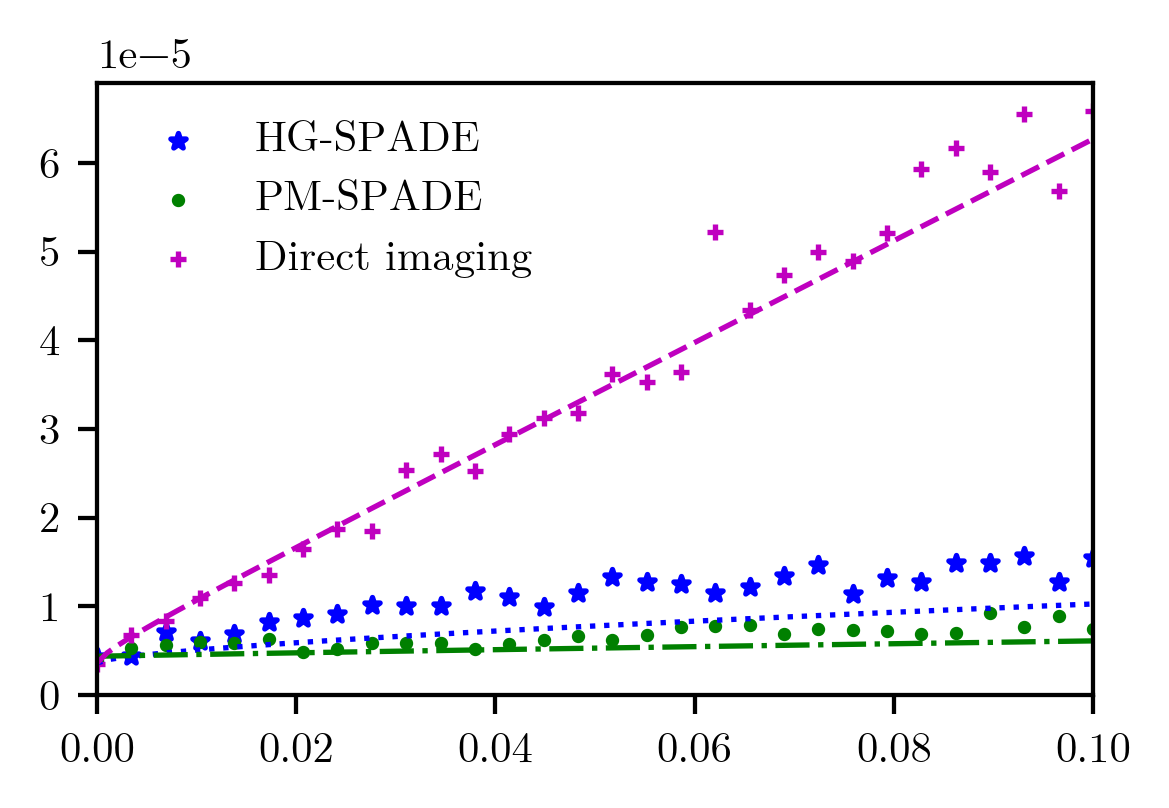

In [37]:
plt.scatter(np.linspace(0, 0.1, 30), np.array(hg_result), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), np.array(pm_result), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), di_result, marker='+', color='m', label=r'Direct imaging')

plt.plot(np.linspace(0, 0.1, 100), 1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), 4*DMD.A(5)/pi, 0.2), 'b:')
plt.plot(np.linspace(0, 0.1, 100), 1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), 4*DMD.A(5)/pi, 0.2), 'g-.')
plt.plot(np.linspace(0, 0.1, 100), 1/DI.CFI(np.linspace(0, 0.1, 100), 4*DMD.A(5)/pi, 0.2), 'm--')

plt.legend(frameon=False)
plt.xlim(0, 0.1)
plt.ylim(0, None)

plt.show()

In [38]:
hg_result = []

for f in np.linspace(0.1, 0.4, 61):
    c = Simulator('hg', DMD.A(5), f).gen()
    c.est()
    hg_result.append(c.estimates.var() * c.photons)


In [49]:
pm_result = []

for f in np.linspace(0.1, 0.4, 61):
    c = Simulator('pm', DMD.A(5), f).gen()
    c.est()
    pm_result.append(c.estimates.var() * c.photons)


In [51]:
di_result = []

for f in np.linspace(0.1, 0.4, 61):
    c = Simulator('di', DMD.A(5), f).gen()
    c.est()
    di_result.append(c.estimates.var() * c.photons)


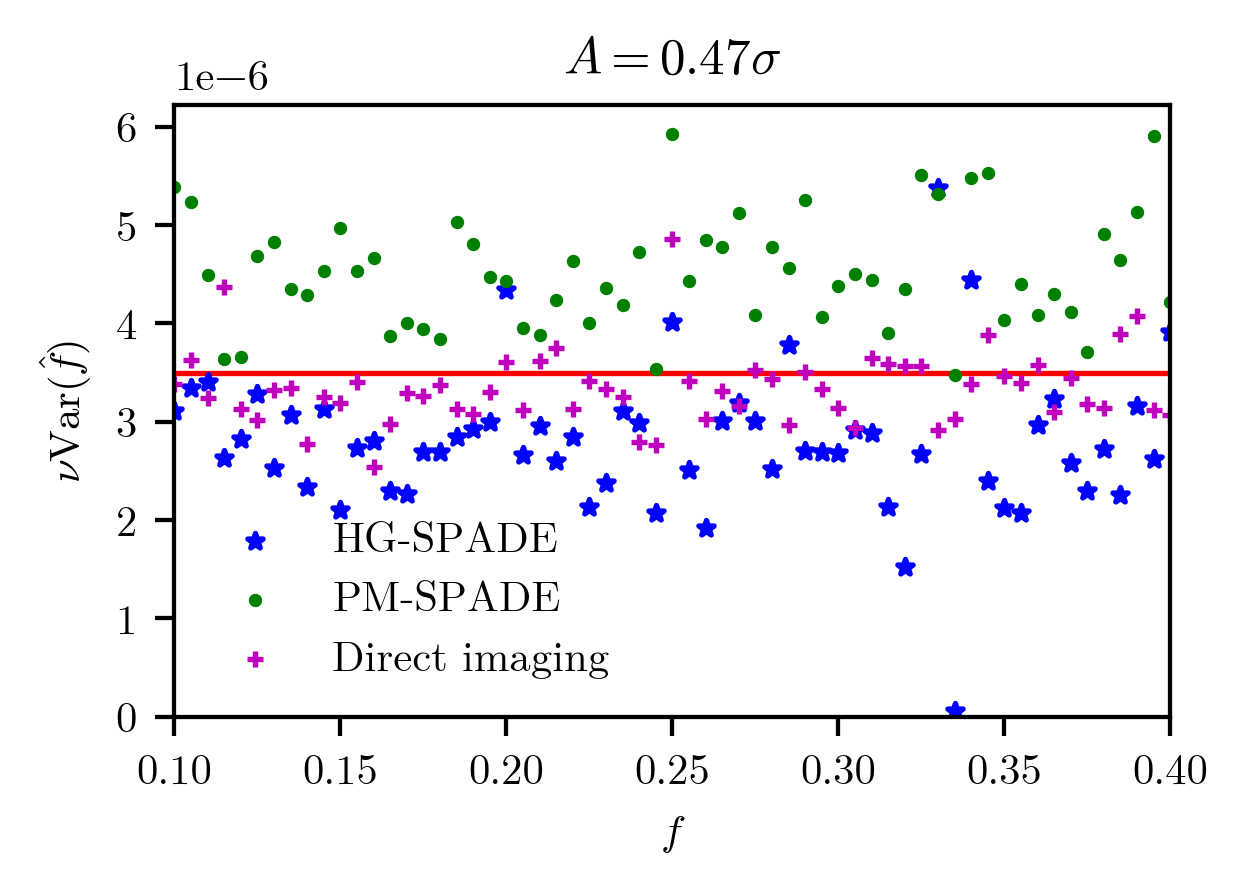

In [64]:
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(hg_result), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(pm_result), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), di_result, marker='+', color='m', label=r'Direct imaging')

plt.axhline(1/DI.ApproxCFI(4*DMD.A(5)/pi), color='red', zorder=0)
plt.xlim(0.1, 0.4)
plt.ylim(0, None)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
plt.title(r'$A=0.47\sigma$')
plt.legend(frameon=False)
plt.show()